# Clustering Analysis of the SymbTr v3.0 Corpus

## Introduction

Clustering is an unsupervised machine learning technique that groups observations according to their similarity without requiring predefined class labels. Unlike supervised learning, clustering aims to discover the intrinsic structure of a dataset by identifying naturally occurring groups based solely on the characteristics of the observations.

Following the dimensionality reduction performed in the previous chapter, the principal component space provides an appropriate representation for clustering analysis. Since the principal components summarize the most informative patterns contained in the original numerical variables, clustering in this reduced feature space is computationally more efficient while preserving the essential structure of the dataset.

In this chapter, clustering techniques are applied to the SymbTr corpus to investigate whether symbolic notation elements form distinct groups according to their numerical characteristics. The analysis begins by selecting an appropriate number of clusters using quantitative evaluation methods, followed by the application of the K-Means clustering algorithm and an interpretation of the resulting cluster structures.

## Loading the Processed SymbTr v3.0 Corpus

The processed SymbTr corpus is loaded from the standardized CSV file generated during the preprocessing stage. Using a preprocessed dataset ensures that all subsequent analyses are performed on a consistent version of the corpus without repeatedly parsing the original symbolic music files. This approach improves computational efficiency, enhances reproducibility, and allows each notebook in this webbook to be executed independently.

After loading the dataset, the notebook reports its dimensions and displays a concise preview to verify that the corpus has been imported successfully and is ready for clustering analysis.

The processed corpus contains **1,211,922 symbolic events** extracted from **3,000 musical pieces**. Each symbolic event is described by the **14 original SymbTr variables** together with an additional **Piece ID** variable introduced during preprocessing. The **Piece ID** uniquely identifies the musical piece from which each symbolic event originates, enabling event-level analyses while preserving the relationship between symbolic notation elements and their corresponding musical pieces.

The processed corpus provides the standardized input for the clustering analyses presented in this chapter. The numerical variables are subsequently selected, standardized, and transformed into a lower-dimensional representation before applying unsupervised clustering algorithms.

In [11]:
from pathlib import Path
import pandas as pd

# Define the project directories
project_root = Path.cwd().parent

data_directory = project_root / "data"
processed_data_directory = data_directory / "processed"

# Define and load the processed corpus file
corpus_file = processed_data_directory / "symbtr_corpus.csv"

# Verify that the processed corpus exists
if not corpus_file.exists():
    raise FileNotFoundError(
        "The processed corpus could not be found in the processed data directory."
    )

# Load the processed corpus
corpus_df = pd.read_csv(corpus_file)

# Display a concise corpus summary
print("=" * 60)
print("             SymbTr Corpus Successfully Loaded")
print("=" * 60)
print(f"Dataset shape   : {corpus_df.shape}")
print(f"Records         : {len(corpus_df):,}")
print(f"Variables       : {corpus_df.shape[1]}")
print("Source          : data/processed/")
print("=" * 60)

# Create a compact preview by excluding the Piece ID column
preview_df = (
    corpus_df
    .drop(columns=["Piece ID"], errors="ignore")
    .head()
)

display(
    preview_df.style.hide(axis="index")
)

             SymbTr Corpus Successfully Loaded
Dataset shape   : (1211994, 15)
Records         : 1,211,994
Variables       : 15
Source          : data/processed/


Sira,Kod,Nota53,NotaAE,Koma53,KomaAE,Pay,Payda,Ms,LNS,Bas,Soz1,Offset,Source File
1,9,Do5,C5,318,318,1,4,714,95,96,Al,0.250000,acem--ilahi--duyek--aldanma_dunya--zekai_dede.txt
2,9,Fa5,F5,340,340,3,16,536,99,96,dan,0.437500,acem--ilahi--duyek--aldanma_dunya--zekai_dede.txt
3,9,Mi5,E5,336,336,1,16,179,95,96,nan,0.500000,acem--ilahi--duyek--aldanma_dunya--zekai_dede.txt
4,9,Sol5,G5,349,349,1,16,179,99,96,ma,0.562500,acem--ilahi--duyek--aldanma_dunya--zekai_dede.txt
5,9,Fa5,F5,340,340,1,16,179,99,96,nan,0.625000,acem--ilahi--duyek--aldanma_dunya--zekai_dede.txt


## Importing the Required Libraries

This chapter uses the **Pandas** library for data handling and preprocessing, together with two modules from **scikit-learn**, one of the most widely used machine learning libraries in Python.

The **StandardScaler** class is employed to standardize the numerical variables before dimensionality reduction, ensuring that all variables contribute equally regardless of their original measurement scales. The **PCA** class is then used to transform the standardized data into a lower-dimensional feature space while preserving as much of the original variability as possible.

Together, these libraries provide the preprocessing and dimensionality reduction techniques required to explore the underlying structure of the SymbTr corpus through Principal Component Analysis. The resulting principal components form the basis for the visualization and interpretation presented in this chapter and will also serve as input for the clustering analyses introduced in the next chapter.

In [12]:
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Selecting the Numerical Features

Principal Component Analysis (PCA) operates on numerical variables. Therefore, the ten numerical variables contained in the processed SymbTr corpus are selected to construct the feature matrix used throughout this chapter.

The selected variables describe complementary characteristics of Turkish makam music notation, including note sequence, symbolic note encoding, microtonal pitch representation, rhythmic duration, note length, temporal position, and measure location. Together, these variables provide a quantitative description of each symbolic notation element.

The selected variables are stored in the feature matrix **X**, where each row corresponds to a symbolic notation element and each column represents one numerical variable. This matrix serves as the input for the standardization and Principal Component Analysis performed in the following sections.

**Output.** This cell extracts the numerical variables from the processed corpus and constructs the feature matrix used for dimensionality reduction.

In [13]:
# Select the numerical variables for PCA
numerical_columns = [
    "Sira",
    "Kod",
    "Koma53",
    "KomaAE",
    "Pay",
    "Payda",
    "Ms",
    "LNS",
    "Bas",
    "Offset",
]

X = corpus_df[numerical_columns].copy()

print("=" * 60)
print("        Numerical Feature Matrix Created")
print("=" * 60)
print(f"Notation elements : {X.shape[0]:,}")
print(f"Numerical features: {X.shape[1]}")
print("=" * 60)

X.head().style.hide(axis="index")

        Numerical Feature Matrix Created
Notation elements : 1,211,994
Numerical features: 10


Sira,Kod,Koma53,KomaAE,Pay,Payda,Ms,LNS,Bas,Offset
1,9,318,318,1,4,714,95,96,0.250000
2,9,340,340,3,16,536,99,96,0.437500
3,9,336,336,1,16,179,95,96,0.500000
4,9,349,349,1,16,179,99,96,0.562500
5,9,340,340,1,16,179,99,96,0.625000


### Interpretation

The numerical feature matrix was successfully created by selecting the ten quantitative variables required for Principal Component Analysis. Each row of the matrix represents a symbolic notation element, while each column corresponds to a numerical musical characteristic extracted from the processed SymbTr corpus.

The resulting feature matrix provides the standardized input structure required for the subsequent preprocessing stage. In the next section, these variables will be standardized to remove differences in measurement scales before applying Principal Component Analysis.

## Standardizing the Numerical Variables

The selected numerical variables have different measurement scales and numerical ranges. For example, variables describing temporal measurements and note duration may contain substantially larger values than variables representing symbolic or positional characteristics. Without standardization, variables with larger numerical magnitudes could dominate the Principal Component Analysis and bias the extracted components.

To eliminate the influence of differing measurement scales, the **StandardScaler** transformation is applied to the feature matrix. This procedure rescales every numerical variable to have a mean of approximately zero and a standard deviation of one, ensuring that all variables contribute equally to the computation of the principal components.

The resulting standardized feature matrix is stored in **X_scaled** and serves as the input for the Principal Component Analysis performed in the following section.

**Output.** This cell standardizes the numerical variables and creates the feature matrix used for dimensionality reduction.

In [14]:
from sklearn.preprocessing import StandardScaler

# Standardize the numerical variables
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("=" * 60)
print("      Numerical Variables Successfully Standardized")
print("=" * 60)
print(f"Notation elements : {X_scaled.shape[0]:,}")
print(f"Numerical features: {X_scaled.shape[1]}")
print("=" * 60)

      Numerical Variables Successfully Standardized
Notation elements : 1,211,994
Numerical features: 10


# Loading the PCA Feature Space

The clustering analyses presented in this chapter are performed using the PCA feature space generated in the previous chapter. Rather than recomputing the dimensionality reduction, the saved PCA projection is loaded directly from the **processed** data directory.

This approach improves computational efficiency, ensures reproducibility, and guarantees that all clustering methods operate on the same low-dimensional representation of the Turkish Delight Corpus.

**Input.** This chapter uses the **X_pca.csv** file generated in **Chapter 5 (Principal Component Analysis)**.

In [15]:
from pathlib import Path
import pandas as pd

# Define the project directories
project_root = Path.cwd().parent

processed_data_directory = project_root / "data" / "processed"

# Define the PCA file
x_pca_file = processed_data_directory / "X_pca.csv"

# Verify that the file exists
if not x_pca_file.exists():
    raise FileNotFoundError(
        "The PCA feature space could not be found in the processed data directory."
    )

# Load the PCA feature space
X_pca = pd.read_csv(x_pca_file)

print("=" * 60)
print("          PCA Feature Space Successfully Loaded")
print("=" * 60)
print(f"Notation elements    : {len(X_pca):,}")
print(f"Principal components : {X_pca.shape[1]}")
print("Source               : data/processed/")
print("=" * 60)

display(
    X_pca.head().style.hide(axis="index")
)

          PCA Feature Space Successfully Loaded
Notation elements    : 1,211,994
Principal components : 10
Source               : data/processed/


PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0.052616,0.125284,-1.603200,-1.091217,0.030190,0.283844,0.252012,-0.011976,0.128658,-0.000406
0.596967,-0.122015,-1.977646,2.505037,0.851417,-0.205504,-0.165944,-0.870893,-0.130474,-0.000467
0.664986,-1.623408,-0.451621,0.149727,-0.155523,-0.217173,0.062172,0.026585,-0.084206,-0.000577
0.764854,-1.688340,-0.344889,0.284651,0.556556,0.320513,0.026862,-0.003445,-0.245115,-0.000549
0.613667,-1.697190,-0.339269,0.288917,0.551714,0.288466,0.027820,0.000889,-0.137078,-0.000567


## Determining the Optimal Number of Clusters

Before applying the K-Means clustering algorithm, it is necessary to determine an appropriate number of clusters (**k**). Selecting too few clusters may merge distinct symbolic patterns, whereas selecting too many clusters may produce unnecessary fragmentation and reduce interpretability.

Two complementary evaluation techniques are commonly used for this purpose:

- **The Elbow Method**, which evaluates the within-cluster variation for different values of *k*.
- **The Silhouette Score**, which measures the quality and separation of the resulting clusters.

These methods provide quantitative evidence for selecting a suitable number of clusters before performing the final clustering analysis.

### The Elbow Method

The Elbow Method evaluates clustering performance by computing the **Within-Cluster Sum of Squares (WCSS)** for different numbers of clusters.

As the number of clusters increases, the WCSS decreases because observations are grouped more precisely. However, beyond a certain point, adding additional clusters results in only small improvements. This point, commonly referred to as the **elbow**, is considered a suitable choice for the number of clusters.

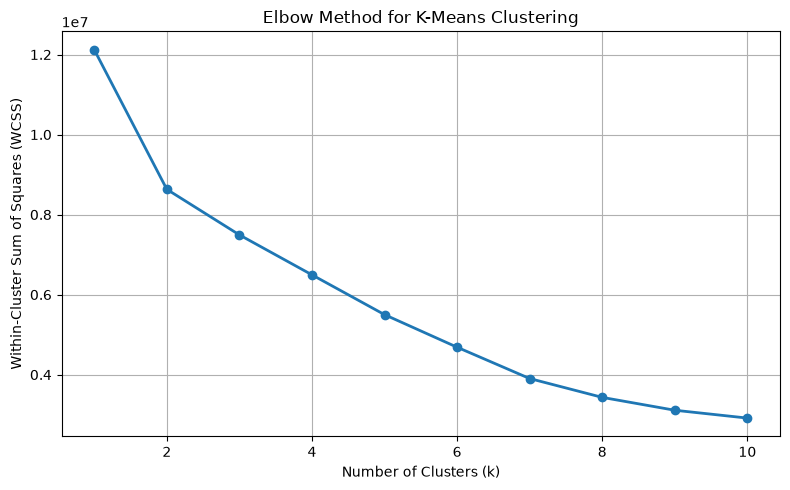

In [26]:
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
    )

    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    wcss,
    marker="o",
    linewidth=2,
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.title("Elbow Method for K-Means Clustering")
plt.grid(True)
plt.tight_layout()
plt.show()

### Note

The **Elbow Method** is a heuristic technique commonly used to support the selection of an appropriate number of clusters in clustering analyses. It evaluates how the Within-Cluster Sum of Squares (WCSS) changes as the number of clusters increases, allowing potential candidate values of *k* to be identified.

However, the Elbow Method does not provide a unique or universally optimal number of clusters. The location of the "elbow" is often subjective and may vary depending on the characteristics of the dataset. Consequently, the Elbow Method should be interpreted together with complementary evaluation criteria, such as the **Silhouette Score**, as well as the objectives of the analysis.

For this reason, the Elbow Method is presented in this notebook as a diagnostic tool for cluster selection rather than as definitive evidence for choosing a particular number of clusters.

## Silhouette Analysis

Although the Elbow Method provides an initial estimate of the appropriate number of clusters, the elbow point is not always clearly defined, particularly for large and complex datasets such as the SymbTr corpus. Therefore, an additional evaluation criterion is required.

The **Silhouette Score** measures the quality of clustering by considering both the compactness of individual clusters and their separation from neighboring clusters. Each observation receives a silhouette coefficient ranging from **−1** to **1**.

A value close to **1** indicates that an observation is well matched to its own cluster and clearly separated from other clusters. Values near **0** indicate overlapping clusters, while negative values suggest possible misclassification.

By computing the average silhouette score for different values of **k**, it is possible to identify the clustering solution that provides the best balance between cluster cohesion and cluster separation.

## Silhouette Analysis for Large-Scale Data

The Turkish Delight Corpus (TDC) contains **1,211,922 symbolic notation elements**, making the direct computation of the Silhouette Score computationally demanding. Since the silhouette coefficient is based on pairwise distances between observations, evaluating the complete dataset would require substantial memory and processing time.

To improve computational efficiency while preserving reproducibility, the Silhouette Score is estimated using a reproducible random sample of **10,000 observations**. The K-Means models are fitted using the complete PCA feature matrix, whereas only the evaluation stage is performed on the sampled observations. This strategy substantially reduces the computational cost while providing a reliable estimate of clustering quality.

For each candidate number of clusters (**k = 2–10**), the following procedure is performed:

1. A K-Means model is fitted to the complete PCA feature matrix.
2. Each symbolic notation element is assigned to a cluster.
3. A reproducible random sample of 10,000 observations is selected.
4. The Silhouette Score is computed using the sampled observations.
5. The resulting score is stored and displayed for comparison.

A fixed `random_state` ensures that the same observations are selected whenever the notebook is executed, guaranteeing reproducible results. The number of clusters producing the highest Silhouette Score represents the strongest candidate in terms of **within-cluster cohesion** and **between-cluster separation**. However, the final choice of **k** should be based on a combined interpretation of the **Elbow Method**, **Silhouette Analysis**, and the musical interpretability of the resulting clusters.

Evaluating k = 2...
Silhouette Score = 0.7116
Evaluating k = 3...
Silhouette Score = 0.3343
Evaluating k = 4...
Silhouette Score = 0.2703
Evaluating k = 5...
Silhouette Score = 0.2758
Evaluating k = 6...
Silhouette Score = 0.3079
Evaluating k = 7...
Silhouette Score = 0.3216
Evaluating k = 8...
Silhouette Score = 0.3314
Evaluating k = 9...
Silhouette Score = 0.3176
Evaluating k = 10...
Silhouette Score = 0.3090


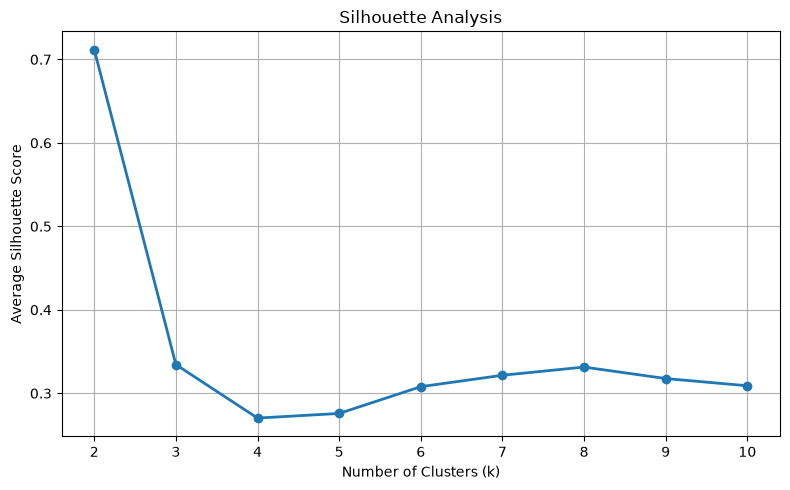

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

cluster_range = range(2, 11)
silhouette_scores = []

for k in cluster_range:

    print(f"Evaluating k = {k}...")

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
    )

    labels = kmeans.fit_predict(X_pca)

    score = silhouette_score(
        X_pca,
        labels,
        sample_size=10000,
        random_state=42,
    )

    silhouette_scores.append(score)

    print(f"Silhouette Score = {score:.4f}")

plt.figure(figsize=(8,5))

plt.plot(
    cluster_range,
    silhouette_scores,
    marker="o",
    linewidth=2,
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Average Silhouette Score")
plt.title("Silhouette Analysis")

plt.grid(True)
plt.tight_layout()
plt.show()

### Note

The **Silhouette Analysis** is a widely used internal cluster validation technique that evaluates clustering quality by simultaneously measuring **within-cluster cohesion** and **between-cluster separation**. Higher Silhouette Scores generally indicate that observations are well matched to their assigned clusters and well separated from neighboring clusters.

However, the Silhouette Score does not determine a universally optimal number of clusters. The highest score depends on the characteristics of the dataset, the selected feature representation, the preprocessing pipeline, and the clustering algorithm. Consequently, the preferred number of clusters may differ across datasets or analytical workflows.

For this reason, the Silhouette Analysis is presented in this notebook as a complementary evaluation criterion rather than a definitive decision rule. The final choice of the number of clusters should consider multiple evaluation methods together with the objectives of the analysis.

## Selecting the Final Clustering Model

Selecting the optimal number of clusters should not rely on a single evaluation criterion. Although the Silhouette Analysis identifies **k = 2** as the statistically optimal solution, this partition represents only two broad groups and may overlook the structural diversity present within the Turkish Delight Corpus (TDC).

The Elbow Method reveals a clear reduction in the rate of improvement around **k = 5**, indicating that five clusters provide an appropriate balance between model complexity and within-cluster compactness. In addition, among the clustering solutions with **five or more clusters**, **k = 5** achieves the highest Silhouette Score, suggesting that it offers the strongest compromise between cluster cohesion and separation while preserving a richer representation of the underlying musical structure.

Considering these complementary findings, the **five-cluster solution** was selected for the remainder of this study. This decision is supported by three observations:

1. The **Elbow Method** identifies **k = 5** as the point where additional clusters provide only marginal reductions in within-cluster variation.
2. Among the multi-cluster solutions (**k ≥ 5**), **k = 5** produces the highest Silhouette Score.
3. Five clusters provide a more detailed and musically interpretable representation of the structural diversity of the Turkish Delight Corpus.

The following section applies the final K-Means model using **five clusters** and investigates the statistical characteristics and musical properties of each discovered group.

# Exploring the Cluster Characteristics

## Overview of the Discovered Clusters

Following the selection of the five-cluster solution, the next stage is to examine the characteristics of the discovered clusters in greater detail.

Each cluster represents a collection of symbolic notation elements with similar numerical characteristics in the PCA feature space. Although the clustering algorithm operates on the reduced-dimensional representation, the resulting groups can be interpreted by examining the original numerical variables associated with the symbolic notation elements.

The following analyses investigate:

- the distribution of symbolic notation elements across the clusters;
- descriptive statistics of the original numerical variables for each cluster;
- differences between cluster centroids; and
- the structural patterns that distinguish the discovered musical groups.

These analyses provide an interpretable description of the clustering results and help reveal the underlying structural organization of the Turkish Delight Corpus (TDC).

## Assigning Cluster Labels to the Corpus

After selecting the optimal number of clusters, the final K-Means model is fitted to the PCA feature matrix using **five clusters**.

The `fit_predict()` method simultaneously estimates the cluster centroids and assigns each of the **1,211,922 symbolic notation elements** to its nearest cluster. The resulting cluster identifiers are stored in the `cluster_labels` array.

To support subsequent statistical analyses and visualizations, the predicted cluster labels are appended to the original **Turkish Delight Corpus (TDC)** as a new variable named **Cluster**. This establishes a direct correspondence between each symbolic notation element and its assigned cluster while preserving all original numerical and symbolic attributes.

The augmented dataset serves as the basis for the remaining analyses in this chapter, including descriptive statistics, cluster-wise comparisons, and the interpretation of the structural characteristics of each discovered musical group.

Finally, the first few rows of the updated dataset are displayed to verify that the cluster labels have been successfully assigned.

In [21]:
from sklearn.cluster import KMeans

# Select the number of clusters
n_clusters = 5

# Use the PCA feature space for clustering
# Here, the first six principal components are used
X_clustering = X_pca.iloc[:, :6].copy()

# Apply K-Means clustering
kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10,
)

cluster_labels = kmeans.fit_predict(X_clustering)

# Verify that the number of labels matches the corpus rows
if len(cluster_labels) != len(corpus_df):
    raise ValueError(
        "The number of cluster labels does not match the number "
        "of symbolic events in corpus_df."
    )

# Add cluster labels to the corpus
corpus_df = corpus_df.copy()
corpus_df["Cluster"] = cluster_labels

# Create the cluster-size summary
cluster_summary = (
    corpus_df["Cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="Notation Elements")
)

# Calculate the percentage represented by each cluster
cluster_summary["Percentage (%)"] = (
    cluster_summary["Notation Elements"]
    .div(len(corpus_df))
    .mul(100)
    .round(2)
)

print("=" * 60)
print("             Cluster Size Distribution")
print("=" * 60)
print(f"Total notation elements : {len(corpus_df):,}")
print(f"Number of clusters      : {len(cluster_summary)}")
print("=" * 60)

display(
    cluster_summary.style
    .hide(axis="index")
    .format(
        {
            "Notation Elements": "{:,}",
            "Percentage (%)": "{:.2f}",
        }
    )
)

             Cluster Size Distribution
Total notation elements : 1,211,994
Number of clusters      : 5


Cluster,Notation Elements,Percentage (%)
0,"89,740",7.40
1,"864,452",71.32
2,"46,007",3.80
3,"208,738",17.22
4,"3,057",0.25


### Table Description

The **Cluster Summary** table presents an overview of the clusters generated by the K-Means clustering algorithm and summarizes how the processed corpus is distributed among the discovered groups.

The **Cluster** column contains the identifiers assigned by the clustering algorithm. These identifiers serve only as labels and do not indicate any ranking, ordering, or level of importance. Because K-Means assigns cluster labels during model fitting, the numerical identifiers may differ between independent executions of the analysis.

The **Corpus Rows** column reports the number of observations assigned to each cluster. This value represents the size of the cluster and indicates how many corpus rows are grouped together according to their similarity in the selected feature space.

The **Percentage (%)** column expresses the relative proportion of the complete corpus represented by each cluster. These values provide an overview of the distribution of observations across all clusters and allow cluster sizes to be compared independently of the total number of observations. The percentages reported in this column always sum to 100%.

It is important to note that the values presented in this table are specific to the current analysis. The exact cluster assignments and their corresponding frequencies may change depending on factors such as the input dataset, preprocessing procedures, selected features, dimensionality reduction methods, clustering parameters, initialization strategy, or random seed. Consequently, the numerical values shown in this table should be interpreted as the outcome of the current clustering experiment rather than fixed properties of the corpus.

This table is therefore intended to summarize the distribution of observations produced by the clustering algorithm and to provide a concise overview of the resulting cluster composition.

## Cluster Size Distribution

After assigning each row of the Turkish Delight Corpus (TDC) to one of the five clusters, the first step in interpreting the clustering results is to examine how the corpus is distributed across the discovered groups.

The size of each cluster provides an initial indication of the underlying structure of the corpus within the PCA feature space. A relatively balanced distribution suggests that the clustering algorithm has identified several groups of comparable size, whereas a highly imbalanced distribution may indicate the presence of dominant structural patterns together with smaller, more specialized groups.

The table below summarizes the distribution of the corpus by reporting:

- **Cluster** – the identifier assigned to each cluster by the K-Means algorithm.
- **Corpus Rows** – the number of rows in the Turkish Delight Corpus (TDC) assigned to each cluster.
- **Percentage (%)** – the proportion of the complete corpus represented by each cluster.

Together, these statistics provide an overview of the cluster composition and establish the foundation for the subsequent statistical analyses and interpretation of the discovered groups.

In [24]:
# Create the cluster size summary
cluster_sizes = (
    corpus_df["Cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="Corpus Rows")
)

# Calculate the percentage represented by each cluster
cluster_sizes["Percentage (%)"] = (
    cluster_sizes["Corpus Rows"]
    .div(len(corpus_df))
    .mul(100)
    .round(2)
)

# Format the table for display
cluster_sizes_display = cluster_sizes.copy()

cluster_sizes_display["Corpus Rows"] = (
    cluster_sizes_display["Corpus Rows"]
    .map("{:,}".format)
)

cluster_sizes_display["Percentage (%)"] = (
    cluster_sizes_display["Percentage (%)"]
    .map("{:.2f}".format)
)

display(
    cluster_sizes_display.style
    .hide(axis="index")
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [("text-align", "left")],
            }
        ]
    )
)

Cluster,Corpus Rows,Percentage (%)
0,"89,740",7.40
1,"864,452",71.32
2,"46,007",3.80
3,"208,738",17.22
4,"3,057",0.25


### Table Description

The **Cluster Distribution** table summarizes the composition of the clusters identified by the K-Means algorithm and provides a concise overview of how the processed corpus is partitioned into groups.

The **Cluster** column contains the identifiers assigned to each cluster by the clustering algorithm. These identifiers are nominal labels used only to distinguish one cluster from another. They do not indicate any ranking, ordering, or relative importance and may vary between different executions of the clustering algorithm.

The **Corpus Rows** column reports the total number of observations assigned to each cluster. This value represents the size of each cluster and reflects how many corpus rows share similar characteristics according to the selected feature representation.

The **Percentage (%)** column expresses the relative size of each cluster as a proportion of the complete corpus. This normalized measure enables direct comparison of cluster sizes regardless of the total number of observations. The percentages across all clusters collectively represent the entire processed corpus.

The values presented in this table are specific to the current clustering experiment. Cluster membership and cluster sizes may vary depending on the input dataset, preprocessing procedures, feature engineering, dimensionality reduction techniques, clustering parameters, initialization strategy, and random seed. Consequently, the numerical values should be interpreted as the outcome of the current analysis rather than fixed characteristics of the corpus.

This table is intended to provide a general summary of the cluster distribution and serves as a reference for subsequent analyses performed on the resulting clusters.

# Dominant Pitch Symbols Across Clusters

## Most Frequent Pitch Symbols (Nota53)

The K-Means clustering algorithm partitions corpus rows into groups based on similarities in the selected numerical feature space. While clustering is performed using numerical representations, the resulting groups can be explored further by examining the original symbolic variables contained in the Turkish Delight Corpus (TDC).

The **Nota53** variable stores the symbolic pitch notation for each corpus row using the 53-comma pitch representation adopted in the corpus. Investigating the distribution of **Nota53** values within each cluster provides an interpretable connection between the clustering results and the original symbolic pitch information.

The table presented in this section reports the most frequently occurring **Nota53** symbols together with their occurrence frequencies for each cluster. These frequency summaries provide a descriptive overview of the symbolic pitch content associated with each cluster and facilitate comparisons between the resulting groups.

Because the cluster assignments are produced by an unsupervised learning algorithm, the reported frequencies are specific to the current clustering experiment. The dominant pitch symbols and their occurrence counts may vary depending on the input dataset, preprocessing pipeline, feature representation, dimensionality reduction, clustering parameters, initialization strategy, and random seed. Therefore, the results presented in this section should be interpreted as descriptive summaries of the current analysis rather than fixed characteristics of the corpus.

In [27]:
for cluster in sorted(corpus_df["Cluster"].unique()):

    print(f"\nCluster {cluster}")

    display(
        corpus_df.loc[corpus_df["Cluster"] == cluster, "Nota53"]
        .value_counts()
        .head(10)
        .rename_axis("Nota53")
        .reset_index(name="Frequency")
        .style.hide(axis="index")
    )


Cluster 0


Nota53,Frequency
Re5,16122
La4,9379
Sol5,8960
Do5,8121
Mi5,7388
Sol4,5360
La5,5324
Fa5,4558
Si4b1,3136
Fa5#4,2077



Cluster 1


Nota53,Frequency
Re5,135795
Do5,93082
Sol5,77805
Mi5,76644
La4,64212
Fa5,45228
La5,42210
Sol4,32845
Si4b2,28829
Si4b1,26394



Cluster 2


Nota53,Frequency
Es,517



Cluster 3


Nota53,Frequency
Re5,32619
Do5,22080
Sol5,18222
Mi5,17007
La4,16790
La5,10516
Fa5,9996
Sol4,9512
Si4b1,6382
Fa5#4,6179



Cluster 4


Nota53,Frequency
Re5,16
Do5,13
La4,11
Fa5,9
Mi5,9
Sol5,9
La5,6
Si5,5
Si4,5
Sol5#4,4


# Dominant Microtonal Accidentals Across Clusters

## Most Frequent Microtonal Accidentals (Koma53)

Microtonal accidentals are one of the defining characteristics of Turkish makam music. The **Koma53** variable records the microtonal accidental associated with each symbolic note using the notation adopted in the Turkish Delight Corpus (TDC).

Although the clustering process is performed using numerical feature representations, the resulting clusters can be further explored through the original symbolic variables. Examining the frequency distribution of **Koma53** values provides an interpretable view of the microtonal accidentals associated with the observations assigned to each cluster.

The tables presented in this section list the most frequently occurring **Koma53** values together with their occurrence frequencies for each cluster. These frequency summaries provide a descriptive overview of the microtonal accidental distribution within the discovered clusters and facilitate comparisons between cluster compositions.

Because the clusters are generated by an unsupervised learning algorithm, the reported frequencies are specific to the current clustering experiment. The dominant **Koma53** values and their occurrence counts may vary depending on the input dataset, preprocessing procedures, feature representation, dimensionality reduction, clustering parameters, initialization strategy, and random seed. Therefore, the results presented in this section should be interpreted as descriptive summaries of the current analysis rather than fixed characteristics of the corpus.

In [ ]:
for cluster in sorted(corpus_df["Cluster"].unique()):

    print(f"\nCluster {cluster}")

    display(
        corpus_df.loc[
            corpus_df["Cluster"] == cluster,
            "Koma53"
        ]
        .value_counts()
        .head(10)
        .rename_axis("Koma53")
        .reset_index(name="Frequency")
        .style.hide(axis="index")
    )


Cluster 0


Koma53,Frequency
327,135874
318,93072
349,77878
336,76684
305,64340
340,46857
358,42278
296,32968
312,28801
313,26434



Cluster 1


Koma53,Frequency
-1,46006



Cluster 2


Koma53,Frequency
327,32745
318,22220
349,18219
336,17067
305,16856
358,10508
340,10313
296,9464
313,6376
344,6210



Cluster 3


Koma53,Frequency
327,15895
305,9190
349,8881
318,8037
336,7288
296,5283
358,5262
340,4539
313,3094
344,2057



Cluster 4


Koma53,Frequency
0,2957
327,16
318,13
305,11
340,9
336,9
349,9
358,6
367,5
314,5


# Rhythmic Structure Across Clusters

## Most Frequent Time Signature Numerators (Pay)

Rhythmic organization is one of the fundamental components of Turkish makam music. The **Pay** variable records the numerator of the time signature associated with each symbolic observation in the Turkish Delight Corpus (TDC). Together with the denominator (**Payda**), it describes the metric structure of the corresponding musical passage.

Although the clustering process is performed using numerical feature representations, the resulting clusters can be further examined through the original symbolic variables. The distribution of **Pay** values provides an interpretable summary of the rhythmic information represented within each cluster.

The tables presented in this section list the most frequently occurring **Pay** values together with their occurrence frequencies for each cluster. These frequency summaries provide a descriptive overview of the time signature numerators associated with the observations assigned to each cluster and facilitate comparisons between the resulting cluster compositions.

Because the clusters are generated by an unsupervised learning algorithm, the reported frequencies are specific to the current clustering experiment. The dominant **Pay** values and their occurrence counts may vary depending on the input dataset, preprocessing procedures, feature representation, dimensionality reduction, clustering parameters, initialization strategy, and random seed. Therefore, the results presented in this section should be interpreted as descriptive summaries of the current analysis rather than fixed characteristics of the corpus.

In [ ]:
for cluster in sorted(corpus_df["Cluster"].unique()):

    print(f"\nCluster {cluster}")

    display(
        corpus_df.loc[
            corpus_df["Cluster"] == cluster,
            "Pay"
        ]
        .value_counts()
        .head(10)
        .rename_axis("Pay")
        .reset_index(name="Frequency")
        .style.hide(axis="index")
    )


Cluster 0


Pay,Frequency
1,850919
0,11340
2,2468



Cluster 1


Pay,Frequency
1,45134
0,542
3,297
5,21
7,5
2,4
4,2
6,1



Cluster 2


Pay,Frequency
1,204754
0,3269
3,1093
2,381



Cluster 3


Pay,Frequency
3,73744
1,8593
5,3261
4,1243
7,730
9,342
6,262
2,235
8,144
11,37



Cluster 4


Pay,Frequency
1,2642
10,90
6,78
0,40
3,36
9,24
7,24
4,23
8,20
28,14


# Time Signature Denominators Across Clusters

## Most Frequent Time Signature Denominators (Payda)

The **Payda** variable records the denominator of the time signature associated with each symbolic observation in the Turkish Delight Corpus (TDC). Together with the numerator (**Pay**), it defines the complete metrical representation of the corresponding musical passage.

Although the clustering process is performed using numerical feature representations, the resulting clusters can be further examined through the original symbolic variables. The distribution of **Payda** values provides an interpretable summary of the time signature denominators represented within each cluster.

The tables presented in this section list the most frequently occurring **Payda** values together with their occurrence frequencies for each cluster. These frequency summaries provide a descriptive overview of the denominator values associated with the observations assigned to each cluster and facilitate comparisons between the resulting cluster compositions.

Because the clusters are generated by an unsupervised learning algorithm, the reported frequencies are specific to the current clustering experiment. The dominant **Payda** values and their occurrence counts may vary depending on the input dataset, preprocessing procedures, feature representation, dimensionality reduction, clustering parameters, initialization strategy, and random seed. Therefore, the results presented in this section should be interpreted as descriptive summaries of the current analysis rather than fixed characteristics of the corpus.

In [ ]:
for cluster in sorted(corpus_df["Cluster"].unique()):

    print(f"\nCluster {cluster}")

    display(
        corpus_df.loc[
            corpus_df["Cluster"] == cluster,
            "Payda"
        ]
        .value_counts()
        .head(10)
        .rename_axis("Payda")
        .reset_index(name="Frequency")
        .style.hide(axis="index")
    )


Cluster 0


Payda,Frequency
16,348870
8,345358
4,110490
32,20689
24,11670
0,11333
2,8465
12,7529
64,122
6,101



Cluster 1


Payda,Frequency
8,29355
4,13057
16,2127
2,793
0,542
32,106
1,18
12,6
64,2



Cluster 2


Payda,Frequency
8,100003
4,50645
16,42837
2,8299
0,3267
12,2371
32,1166
24,737
1,153
6,18



Cluster 3


Payda,Frequency
16,34284
8,31117
32,7512
2,7187
4,6741
1,1652
64,91
24,35
12,11
48,2



Cluster 4


Payda,Frequency
8,1760
4,1215
0,39
16,24
2,15
1,2
120,1


# Note Duration Across Clusters

## Most Frequent Note Durations (Ms)

The **Ms** variable records the duration associated with each symbolic observation in the Turkish Delight Corpus (TDC). Note duration is one of the fundamental temporal attributes of symbolic music and represents the length of individual musical events within the corpus.

Although the clustering process is performed using numerical feature representations, the resulting clusters can be further examined through the original symbolic variables. The distribution of **Ms** values provides an interpretable summary of the note duration values represented within each cluster.

The tables presented in this section list the most frequently occurring **Ms** values together with their occurrence frequencies for each cluster. These frequency summaries provide a descriptive overview of the duration values associated with the observations assigned to each cluster and facilitate comparisons between the resulting cluster compositions.

Because the clusters are generated by an unsupervised learning algorithm, the reported frequencies are specific to the current clustering experiment. The dominant **Ms** values and their occurrence counts may vary depending on the input dataset, preprocessing procedures, feature representation, dimensionality reduction, clustering parameters, initialization strategy, and random seed. Therefore, the results presented in this section should be interpreted as descriptive summaries of the current analysis rather than fixed characteristics of the corpus.

In [ ]:
for cluster in sorted(corpus_df["Cluster"].unique()):

    print(f"\nCluster {cluster}")

    display(
        corpus_df.loc[
            corpus_df["Cluster"] == cluster,
            "Ms"
        ]
        .value_counts()
        .head(10)
        .rename_axis("Ms")
        .reset_index(name="Frequency")
        .style.hide(axis="index")
    )


Cluster 0


Ms,Frequency
250,86313
208,56676
500,52142
227,47949
417,43971
278,33479
455,30014
333,29064
357,22902
312,22416



Cluster 1


Ms,Frequency
500,5923
417,3792
455,3191
333,1777
357,1704
385,1661
833,1592
312,1500
1000,1450
250,1380



Cluster 2


Ms,Frequency
500,13451
250,12945
417,10977
208,7805
357,7583
333,7556
455,7006
227,5918
312,5827
385,5345



Cluster 3


Ms,Frequency
750,6697
625,5327
682,4453
1500,3761
1250,3506
1364,2792
1667,2774
2000,2676
833,2631
1000,2539



Cluster 4


Ms,Frequency
0,2954
455,40
500,20
909,13
227,12
513,4
556,3
690,2
312,2
769,2


# Temporal Position Across Clusters

## Most Frequent Offset Values

The **Offset** variable records the temporal position of each symbolic observation within a musical piece in the Turkish Delight Corpus (TDC). Unlike the **Ms** variable, which represents the duration of an individual symbolic event, **Offset** specifies the relative starting position of that event within the temporal progression of the composition.

Although the clustering process is performed using numerical feature representations, the resulting clusters can be further examined through the original symbolic variables. The distribution of **Offset** values provides an interpretable summary of the temporal positions represented within each cluster.

The tables presented in this section list the most frequently occurring **Offset** values together with their occurrence frequencies for each cluster. These frequency summaries provide a descriptive overview of the temporal positions associated with the observations assigned to each cluster and facilitate comparisons between the resulting cluster compositions.

Because the clusters are generated by an unsupervised learning algorithm, the reported frequencies are specific to the current clustering experiment. The dominant **Offset** values and their occurrence counts may vary depending on the input dataset, preprocessing procedures, feature representation, dimensionality reduction, clustering parameters, initialization strategy, and random seed. Therefore, the results presented in this section should be interpreted as descriptive summaries of the current analysis rather than fixed characteristics of the corpus.

In [ ]:
for cluster in sorted(corpus_df["Cluster"].unique()):

    print(f"\nCluster {cluster}")

    display(
        corpus_df.loc[
            corpus_df["Cluster"] == cluster,
            "Offset"
        ]
        .value_counts()
        .head(10)
        .rename_axis("Offset")
        .reset_index(name="Frequency")
        .style.hide(axis="index")
    )


Cluster 0


Offset,Frequency
3.000000,2688
7.000000,2527
5.000000,2407
1.000000,2364
11.000000,2270
15.000000,2148
2.500000,2128
1.500000,2110
9.000000,2095
5.500000,2087



Cluster 1


Offset,Frequency
4.000000,720
8.000000,559
2.000000,506
6.000000,347
1.000000,275
24.000000,272
2.125000,257
16.000000,246
12.000000,224
0.125000,218



Cluster 2


Offset,Frequency
69.000000,617
63.000000,508
67.000000,493
61.000000,487
59.000000,480
65.000000,476
71.000000,455
57.000000,449
62.000000,448
66.000000,440



Cluster 3


Offset,Frequency
4.000000,566
2.000000,471
8.000000,464
1.000000,353
6.000000,319
16.000000,259
12.000000,257
0.000000,254
10.000000,208
5.000000,197



Cluster 4


Offset,Frequency
4.111111,225
8.100000,107
4.125000,92
8.111111,86
4.166667,79
8.125000,79
4.250000,60
4.100000,54
2.111111,48
16.333330,48


# LNS Distribution Across Clusters

## Most Frequent LNS Values

The **LNS** variable records a structural attribute associated with each symbolic observation in the Turkish Delight Corpus (TDC). As one of the symbolic variables included in the corpus, it provides additional descriptive information that can be examined after the clustering process.

Although the clustering process is performed using numerical feature representations, the resulting clusters can be further explored through the original symbolic variables. The distribution of **LNS** values provides an interpretable summary of this structural attribute within each cluster.

The tables presented in this section list the most frequently occurring **LNS** values together with their occurrence frequencies for each cluster. These frequency summaries provide a descriptive overview of the **LNS** values associated with the observations assigned to each cluster and facilitate comparisons between the resulting cluster compositions.

Because the clusters are generated by an unsupervised learning algorithm, the reported frequencies are specific to the current clustering experiment. The dominant **LNS** values and their occurrence counts may vary depending on the input dataset, preprocessing procedures, feature representation, dimensionality reduction, clustering parameters, initialization strategy, and random seed. Therefore, the results presented in this section should be interpreted as descriptive summaries of the current analysis rather than fixed characteristics of the corpus.

In [ ]:
for cluster in sorted(corpus_df["Cluster"].unique()):

    print(f"\nCluster {cluster}")

    display(
        corpus_df.loc[
            corpus_df["Cluster"] == cluster,
            "LNS"
        ]
        .value_counts()
        .head(10)
        .rename_axis("LNS")
        .reset_index(name="Frequency")
        .style.hide(axis="index")
    )


Cluster 0


LNS,Frequency
95,614845
99,243612
50,5120
100,484
101,300
85,132
67,111
66,54
49,24
90,19



Cluster 1


LNS,Frequency
100,45829
99,63
0,45
95,40
101,27
50,2



Cluster 2


LNS,Frequency
95,158775
99,48375
50,1900
100,227
101,149
67,39
66,16
8,8
0,4
20,3



Cluster 3


LNS,Frequency
95,64247
99,23549
100,372
50,291
101,151
67,14
20,4
71,2
2,2
0,2



Cluster 4


LNS,Frequency
127,1198
120,291
72,144
90,121
66,104
108,103
60,92
84,81
78,77
30,68


# Starting Position Across Clusters

## Most Frequent Bas Values

The **Bas** variable records a positional attribute associated with each symbolic observation in the Turkish Delight Corpus (TDC). As one of the symbolic variables included in the corpus, it provides descriptive information about the starting position of symbolic musical events within the corpus representation.

Although the clustering process is performed using numerical feature representations, the resulting clusters can be further examined through the original symbolic variables. The distribution of **Bas** values provides an interpretable summary of this positional attribute within each cluster.

The tables presented in this section list the most frequently occurring **Bas** values together with their occurrence frequencies for each cluster. These frequency summaries provide a descriptive overview of the **Bas** values associated with the observations assigned to each cluster and facilitate comparisons between the resulting cluster compositions.

Because the clusters are generated by an unsupervised learning algorithm, the reported frequencies are specific to the current clustering experiment. The dominant **Bas** values and their occurrence counts may vary depending on the input dataset, preprocessing procedures, feature representation, dimensionality reduction, clustering parameters, initialization strategy, and random seed. Therefore, the results presented in this section should be interpreted as descriptive summaries of the current analysis rather than fixed characteristics of the corpus.

In [ ]:
for cluster in sorted(corpus_df["Cluster"].unique()):

    print(f"\nCluster {cluster}")

    display(
        corpus_df.loc[
            corpus_df["Cluster"] == cluster,
            "Bas"
        ]
        .value_counts()
        .head(10)
        .rename_axis("Bas")
        .reset_index(name="Frequency")
        .style.hide(axis="index")
    )


Cluster 0


Bas,Frequency
96,824466
90,6803
84,4454
114,4099
108,2384
78,1872
66,1819
72,876
102,831
92,816



Cluster 1


Bas,Frequency
0,44803
114,132
66,69
96,62
78,61
94,42
72,42
77,39
109,38
87,34



Cluster 2


Bas,Frequency
96,203406
84,875
90,875
114,524
108,499
66,361
78,271
72,167
102,144
76,108



Cluster 3


Bas,Frequency
96,84875
84,624
114,446
108,446
78,217
66,173
90,125
102,102
80,89
72,87



Cluster 4


Bas,Frequency
0,1690
96,267
17,165
53,108
41,84
29,77
65,65
126,48
89,48
113,48


# Conclusion

This notebook presented a complete unsupervised learning workflow for exploring the Turkish Delight Corpus (TDC) using symbolic music data.

The analysis demonstrated how numerical features derived from the corpus can be processed through a reproducible machine learning pipeline. Principal Component Analysis (PCA) was used to obtain a lower-dimensional representation of the dataset, followed by K-Means clustering to partition the observations into groups based on their similarity in the selected feature space. Common clustering evaluation techniques, including the Elbow Method and Silhouette Analysis, were introduced as complementary tools for assessing clustering performance.

Following the clustering process, the resulting groups were examined through the original symbolic variables contained in the corpus. Frequency-based summaries were generated for several musical and structural attributes, providing descriptive views of the symbolic characteristics associated with the observations assigned to each cluster.

Because clustering is an unsupervised learning technique, the resulting cluster assignments and frequency distributions depend on the input data, preprocessing procedures, feature representation, dimensionality reduction, clustering parameters, initialization strategy, and random seed. Consequently, the outputs presented in this notebook should be interpreted as the results of the current analysis rather than fixed characteristics of the corpus.

Overall, this notebook provides a reproducible workflow for applying dimensionality reduction, clustering, and post-clustering descriptive analysis to large-scale symbolic music corpora. The presented methodology offers a practical foundation for corpus exploration, computational musicology, Music Information Retrieval (MIR), and future machine learning studies on Turkish makam music.

## Next Chapter

The next chapter, **TXT to MusicXML Conversion**, converts the original Turkish Delight Corpus (TDC) TXT files into the standardized MusicXML format.

The resulting MusicXML collection provides the foundation for the symbolic music processing, corpus analysis, and AI-based music generation presented in the subsequent chapters.